# CLASP controls — figure-ready pipeline

Load literature cleavage controls from `assets/experiments/analysis/08_26/20_clasp_analysis_karol/configs/clasp-controls.tsv`, score **unique**
peptides (one row per `peptide_id`, protease annotations aggregated) on the
**S. aureus** MEROPS panel (dataset **7**), and export:

1. A peptide table with sequence, aggregated literature roles, known cuts, and APEX
   *S. aureus* ATCC 12600 **log2 MIC** (mean ± ensemble SD)
2. DBAASP Φ<sub>cleav</sub> histogram / length scatter with controls highlighted
3. Mutation ΔΦ heatmaps with known cut sites marked
4. Per-enzyme aureolysin / V8 scores and CLASP potential with APEX ensemble SD

Host-only annotations (HNE, KLK, cathepsin, mouse serum) stay in the long table
but Φ uses MEROPS dataset 7 only.


In [1]:
from pathlib import Path
import math
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src" / "pep_compass").is_dir()),
    cwd,
)
sys.path.insert(0, str(project_root / "src"))

CONTROLS_TSV = (
    project_root
    / "assets"
    / "experiments"
    / "analysis"
    / "08_26"
    / "20_clasp_analysis_karol"
    / "configs"
    / "clasp-controls.tsv"
)
ALL_IN_CSV = project_root / "data" / "peptides_data" / "peptides_mic" / "peptides_apex.csv"
OUT_DIR = project_root / "experiments" / "results" / "clasp_controls_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIC_COLUMN = "S. aureus ATCC 12600"
MEROPS_DATASETS = (7,)
VARIANT = "product"
LAM = 0.1
DEVICE = "cpu"

PRIMARY_PANEL = "eskape_saureus"
FOCUS_ENZYMES = {
    "M04.009": "aureolysin (Aur)",
    "S01.269": "V8 / glutamyl endopeptidase I",
}
ROLE_COLORS = {
    "stable": "#2ca02c",
    "labile": "#d62728",
    "counterexample": "#9467bd",
    "mixed": "#7f7f7f",
}
EMPTY_SITES = {"unmapped", "unassigned", "none", "none_reported", ""}

print("project_root:", project_root)
print("controls:", CONTROLS_TSV, "exists=", CONTROLS_TSV.exists())
print("all_in:", ALL_IN_CSV, "exists=", ALL_IN_CSV.exists())
print("MIC:", MIC_COLUMN, "MEROPS:", MEROPS_DATASETS, "LAM:", LAM)


project_root: /home/max/repositories/pep-compass
controls: /home/max/repositories/pep-compass/assets/experiments/analysis/08_26/20_clasp_analysis_karol/configs/clasp-controls.tsv exists= True
all_in: /home/max/repositories/pep-compass/data/peptides_data/peptides_mic/peptides_apex.csv exists= True
MIC: S. aureus ATCC 12600 MEROPS: (7,) LAM: 0.1


## Load `clasp-controls.tsv`

Keep the long peptide×protease annotation table, then collapse to unique
peptides with a compact roles string and high-confidence cut sites.


In [2]:
ann = pd.read_csv(CONTROLS_TSV, sep="\t")
assert len(ann) > 0
print(f"annotation rows: {len(ann)}")
print(f"unique peptides: {ann['peptide_id'].nunique()}")
print(ann[["peptide_id", "protease", "class", "panel", "confidence", "cleavage_sites"]].to_string(index=False))


def parse_sites(sequence: str, sites_str: str) -> list[tuple[int, str]]:
    """Parse 'R19|I20;E16|F17' into (0-based bond index, label)."""
    if sites_str is None or str(sites_str).strip() in EMPTY_SITES:
        return []
    out: list[tuple[int, str]] = []
    for tok in str(sites_str).split(";"):
        tok = tok.strip()
        m = re.fullmatch(r"([A-Z])(\d+)\|([A-Z])(\d+)", tok)
        if not m:
            continue
        p1_aa, p1_pos = m.group(1), int(m.group(2))
        p1p_aa, p1p_pos = m.group(3), int(m.group(4))
        bond_i = p1_pos - 1
        if not (0 <= bond_i < len(sequence) - 1):
            continue
        if sequence[bond_i] != p1_aa or sequence[bond_i + 1] != p1p_aa:
            label = f"{tok}?"
        else:
            label = tok
        if p1_pos + 1 != p1p_pos:
            label = f"{tok}*"
        out.append((bond_i, label))
    return out


def roles_string(group: pd.DataFrame) -> str:
    parts = []
    for _, r in group.iterrows():
        parts.append(f"{r['class']}@{r['protease']}")
    return "; ".join(parts)


def primary_role(group: pd.DataFrame) -> str:
    sa = group[group["panel"] == PRIMARY_PANEL]
    use = sa if len(sa) else group
    classes = sorted(set(use["class"].astype(str)))
    if len(classes) == 1:
        return classes[0]
    return "mixed"


def high_sites_pretty(group: pd.DataFrame, sequence: str) -> str:
    bits = []
    for _, r in group.iterrows():
        if str(r["confidence"]) != "high":
            continue
        parsed = parse_sites(sequence, r["cleavage_sites"])
        if not parsed:
            continue
        site_txt = ",".join(lab for _, lab in parsed)
        bits.append(f"{r['protease']}:{site_txt}")
    return "; ".join(bits)


def known_bonds_for_heatmap(group: pd.DataFrame, sequence: str) -> list[tuple[int, str]]:
    bonds: list[tuple[int, str]] = []
    seen: set[int] = set()
    ordered = pd.concat(
        [
            group[group["merops_id"].isin(FOCUS_ENZYMES.keys())],
            group[~group["merops_id"].isin(FOCUS_ENZYMES.keys())],
        ]
    )
    for _, r in ordered.iterrows():
        if str(r["confidence"]) != "high":
            continue
        short = {
            "aureolysin": "Aur",
            "V8_SspA": "V8",
            "LasB_pseudolysin": "LasB",
            "sa_supernatant": "SAsup",
        }.get(str(r["protease"]), str(r["protease"])[:6])
        for bond_i, lab in parse_sites(sequence, r["cleavage_sites"]):
            if bond_i in seen:
                continue
            seen.add(bond_i)
            bonds.append((bond_i, f"{short} {lab}"))
    return bonds


rows = []
for pep_id, g in ann.groupby("peptide_id", sort=False):
    seq = str(g["sequence"].iloc[0])
    dois = sorted({str(x) for x in g["source_id"].dropna()})
    rows.append(
        {
            "peptide_id": pep_id,
            "sequence": seq,
            "length": len(seq),
            "primary_role": primary_role(g),
            "roles": roles_string(g),
            "known_sites": high_sites_pretty(g, seq),
            "source_ids": "; ".join(dois),
            "n_annotations": len(g),
        }
    )

peptides = pd.DataFrame(rows).reset_index(drop=True)
peptides["ctrl_color"] = peptides["primary_role"].map(ROLE_COLORS).fillna("#7f7f7f")

KNOWN_BONDS = {
    pep_id: known_bonds_for_heatmap(g, str(g["sequence"].iloc[0]))
    for pep_id, g in ann.groupby("peptide_id", sort=False)
}

print("\nunique peptides:")
print(
    peptides[
        ["peptide_id", "length", "primary_role", "known_sites", "n_annotations"]
    ].to_string(index=False)
)
ann_path = OUT_DIR / "clasp_controls_annotations_long.csv"
ann.to_csv(ann_path, index=False)
print("wrote", ann_path)


annotation rows: 28
unique peptides: 13
peptide_id         protease          class              panel confidence            cleavage_sites
     LL-37       aureolysin         labile     eskape_saureus       high   R19|I20;R23|I24;L31|V32
     LL-37          V8_SspA         labile     eskape_saureus       high                   E16|F17
     LL-37 LasB_pseudolysin         labile eskape_paeruginosa   inferred   E16|F17;R19|I20;R23|I24
     LL-37  GelE_coccolysin         labile   eskape_efaecalis     medium                  unmapped
     LL-37             ZapA         labile   other_pmirabilis     medium                  unmapped
  LL-17-37          V8_SspA         stable     eskape_saureus       high                      none
  LL-17-37       aureolysin         labile     eskape_saureus   inferred       R3|I4;R7|I8;L15|V16
     EFK17       aureolysin         labile     eskape_saureus       high             R4|I5;D11|F12
     EFK17          V8_SspA         labile     eskape_saureus       h

## DBAASP background + MEROPS panel 7

Score DBAASP sequences and the unique controls with product-variant
Φ<sub>cleav</sub> on the *S. aureus* protease panel.


In [3]:
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    load_protease_panel,
)

raw = pd.read_csv(ALL_IN_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
dbaasp = (
    raw[raw["dataset"].str.contains("dbaasp", case=False, na=False)]
    .drop_duplicates(subset=["sequence"])
    .reset_index(drop=True)
)
dbaasp["length"] = dbaasp["sequence"].str.len()
dbaasp["mic_uM"] = dbaasp[MIC_COLUMN].astype(float)
dbaasp["log2_mic"] = np.log2(dbaasp["mic_uM"])

panel = load_protease_panel(MEROPS_DATASETS, device=DEVICE)
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)
print(f"DBAASP peptides: {len(dbaasp)}")
print(f"panel proteases: {panel.matrices.shape[0]}")
print("focus enzymes present:", {c: c in list(cleavage.codes) for c in FOCUS_ENZYMES})

phi = (
    cleavage.sequence_log_potential(dbaasp["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
dbaasp["cleavage"] = phi
dbaasp["cleavage_term"] = LAM * dbaasp["cleavage"]
dbaasp["potential"] = dbaasp["log2_mic"] + dbaasp["cleavage_term"]

phi_ctrl = (
    cleavage.sequence_log_potential(peptides["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
peptides["cleavage"] = phi_ctrl
peptides["cleavage_term"] = LAM * peptides["cleavage"]

phi_ref = np.sort(dbaasp["cleavage"].to_numpy())
peptides["dbaasp_percentile"] = [
    100.0 * float(np.searchsorted(phi_ref, v, side="right") / len(phi_ref))
    for v in peptides["cleavage"]
]
peptides["in_dbaasp"] = peptides["sequence"].isin(set(dbaasp["sequence"]))

dbaasp_path = OUT_DIR / "dbaasp_saureus_cleavage.csv"
dbaasp.to_csv(dbaasp_path, index=False)
print("wrote", dbaasp_path)
print(
    peptides[
        ["peptide_id", "primary_role", "cleavage", "dbaasp_percentile", "in_dbaasp"]
    ]
    .sort_values("cleavage", ascending=False)
    .to_string(index=False)
)


DBAASP peptides: 3038
panel proteases: 55
focus enzymes present: {'M04.009': True, 'S01.269': True}


wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/dbaasp_saureus_cleavage.csv
peptide_id   primary_role   cleavage  dbaasp_percentile  in_dbaasp
     LL-37         labile -15.875489          92.988808      False
       CAM         labile -15.988631          90.190915      False
     Onc18         labile -16.066711          86.866359       True
     CAM-W         stable -16.109816          84.726794      False
     hBD-3         labile -16.175388          81.270573      False
      bCAT         labile -16.226362          78.703094      False
     hBD-2         labile -16.302172          74.753127      False
      hCAT         labile -16.350233          72.284398      False
     GKY25         labile -16.546692          58.986175       True
  LL-17-37          mixed -16.557772          58.097433      False
     EFK17         labile -16.775751          45.951284      False
      bCTL counterexample -16.930038          38.808427      False
   EFK17-W       

## Figure table — names, formulas, log2 MIC (APEX ensemble)

One row per unique peptide from `clasp-controls.tsv` (protease annotations
aggregated). APEX `model="full"` mean ± SD of **log2 MIC** for *S. aureus*
ATCC 12600. Shown as a pandas DataFrame; also written to CSV.


In [4]:
from pep_compass.optimization.components.oracles.strategies.apex_original.predictor import PredictorAPEX
from pep_compass.optimization.components.oracles.strategies.apex_original.utils import onehot_encoding

apex = PredictorAPEX(device=DEVICE, model="full")
mic_idx = apex.pathogen_list.index(MIC_COLUMN)


def apex_ensemble_mic_uM(sequences: list[str]) -> np.ndarray:
    """Return MIC predictions per ensemble model, shape (n_models, n_seq)."""
    data_len = len(sequences)
    per_model = []
    for model in apex.APEX_models:
        model = model.to(apex.device).eval()
        parts = []
        for i in range(int(math.ceil(data_len / float(apex.batch_size)))):
            batch = sequences[i * apex.batch_size : (i + 1) * apex.batch_size]
            x = torch.LongTensor(
                onehot_encoding(batch, apex.max_len, apex.word2idx)
            ).to(apex.device)
            pred = model(x).cpu().detach().numpy()
            parts.append(10 ** (6 - pred))
        per_model.append(np.vstack(parts)[:, mic_idx])
    return np.stack(per_model, axis=0)


assert peptides["peptide_id"].is_unique
assert len(peptides) == ann["peptide_id"].nunique()

mic_ens = apex_ensemble_mic_uM(peptides["sequence"].tolist())
log2_ens = np.log2(np.clip(mic_ens, 1e-12, None))

peptides["log2_mic"] = log2_ens.mean(axis=0)
peptides["log2_mic_sd"] = log2_ens.std(axis=0, ddof=1)
peptides["mic_source"] = "apex"
peptides["potential"] = peptides["log2_mic"] + peptides["cleavage_term"]
peptides["potential_sd"] = peptides["log2_mic_sd"]
peptides["n_ensemble"] = int(mic_ens.shape[0])

fig_table = peptides[
    [
        "peptide_id",
        "sequence",
        "length",
        "primary_role",
        "roles",
        "known_sites",
        "log2_mic",
        "log2_mic_sd",
        "cleavage",
        "dbaasp_percentile",
        "potential",
        "potential_sd",
        "mic_source",
        "n_annotations",
        "source_ids",
    ]
].copy()

assert fig_table["peptide_id"].is_unique
assert len(fig_table) == len(peptides)

table_path = OUT_DIR / "controls_figure_table.csv"
fig_table.to_csv(table_path, index=False)
print("wrote", table_path)

# Pandas DataFrame for notebook display (rounded numerics).
display_cols = [
    "peptide_id",
    "sequence",
    "length",
    "primary_role",
    "roles",
    "known_sites",
    "log2_mic",
    "log2_mic_sd",
    "cleavage",
    "dbaasp_percentile",
    "potential",
    "potential_sd",
]
fig_table_display = fig_table[display_cols].copy()
for col in ["log2_mic", "log2_mic_sd", "cleavage", "dbaasp_percentile", "potential", "potential_sd"]:
    fig_table_display[col] = fig_table_display[col].astype(float).round(3)

fig_table_display


wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/controls_figure_table.csv


,peptide_id,sequence,length,primary_role,roles,known_sites,log2_mic,log2_mic_sd,cleavage,dbaasp_percentile,potential,potential_sd
0,LL-37,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,labile,labile@aureolysin; labile@V8_SspA; labile@LasB...,"aureolysin:R19|I20,R23|I24,L31|V32; V8_SspA:E1...",6.177,0.667,-15.875,92.989,4.589,0.667
1,LL-17-37,FKRIVQRIKDFLRNLVPRTES,21,mixed,stable@V8_SspA; labile@aureolysin,,6.104,0.755,-16.558,58.097,4.448,0.755
2,EFK17,EFKRIVQRIKDFLRNLV,17,labile,labile@aureolysin; labile@V8_SspA; labile@LasB...,"aureolysin:R4|I5,D11|F12; V8_SspA:E1|F2; LasB_...",5.271,1.124,-16.776,45.951,3.593,1.124
3,EFK17-W,EWKRWVQRWKDWLRNLV,17,stable,stable@aureolysin; stable@V8_SspA; stable@HNE_...,,4.926,1.125,-17.428,19.059,3.183,1.125
4,bCAT,RSMRLSFRARGYGFRGPGLQL,21,labile,labile@sa_supernatant,"sa_supernatant:L5|S6,G13|F14",5.339,0.935,-16.226,78.703,3.716,0.935
5,hCAT,SSMKLSFRARGYGFRGPGPQL,21,labile,labile@sa_supernatant,"sa_supernatant:L5|S6,G13|F14",6.772,0.195,-16.350,72.284,5.137,0.195
6,bCTL,RSMRLSFRARGYGFR,15,counterexample,counterexample@sa_supernatant,,4.888,0.955,-16.930,38.808,3.195,0.955
7,GKY25,GKYGFYTHVFRLKKWIQKVIDQFGE,25,labile,labile@aureolysin,,5.654,0.913,-16.547,58.986,3.999,0.913
8,hBD-3,GIINTLQKYYCRVRGGRCAVLSCLPKEEQIGKCSTRGRKCCRRKK,45,labile,labile@cathepsin_B_L_S,,5.955,1.111,-16.175,81.271,4.338,1.111
9,hBD-2,GIGDPVTCLKSGAICHPVFCPRRYKQIGTCGLPGTKCCKKP,41,labile,labile@cathepsin_B_L_S,,6.984,0.192,-16.302,74.753,5.354,0.192


## DBAASP overlay — histogram and length scatter

Color by primary literature role (`eskape_saureus` preferred). Protease-conditional
peptides (e.g. EFK17-W) may be `mixed`.


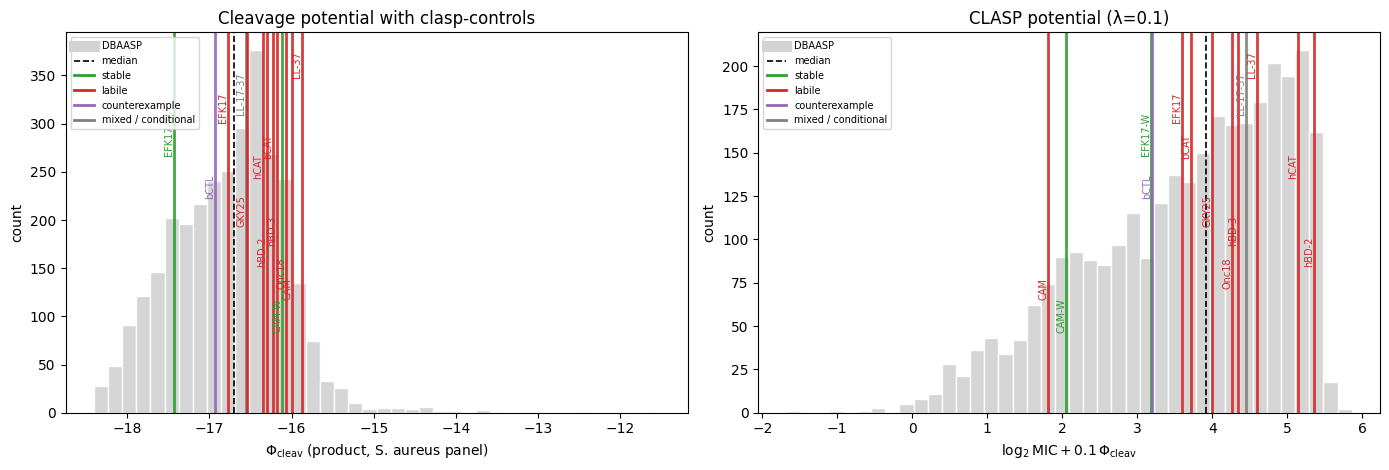

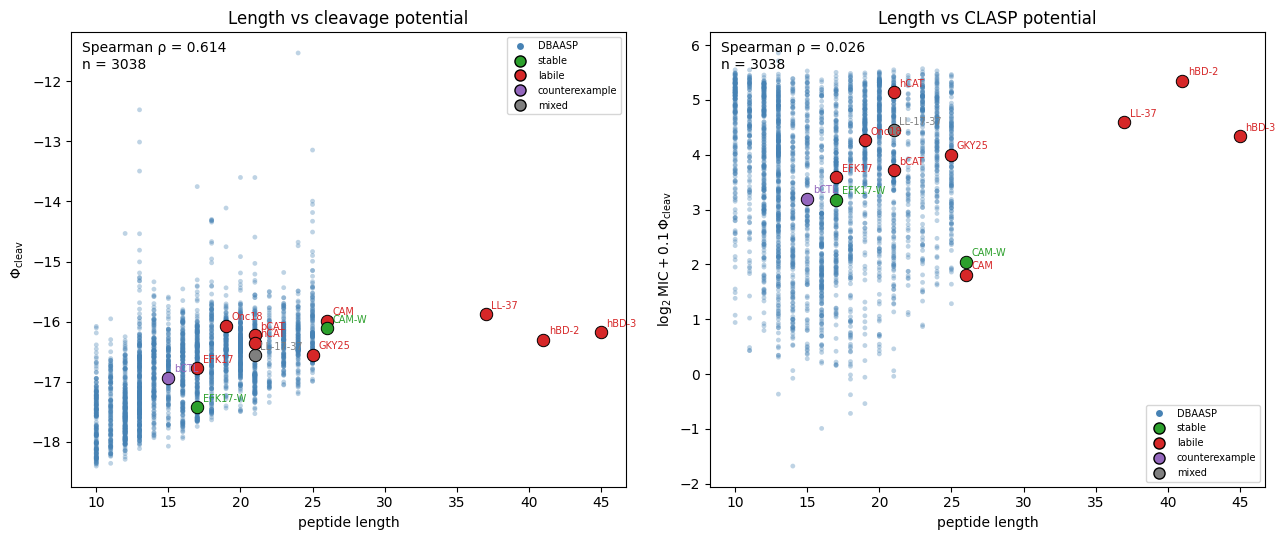

In [5]:
def overlay_vlines(ax, frame, value_col):
    y_fracs = np.linspace(0.95, 0.30, len(frame))
    for i, (_, row) in enumerate(frame.iterrows()):
        color = row["ctrl_color"]
        ax.axvline(row[value_col], color=color, lw=2.0, alpha=0.9)
        ax.text(
            row[value_col],
            ax.get_ylim()[1] * y_fracs[i],
            row["peptide_id"],
            rotation=90,
            va="top",
            ha="right",
            fontsize=7,
            color=color,
        )


def overlay_scatter(ax, frame, y_col):
    for _, row in frame.iterrows():
        ax.scatter(
            row["length"],
            row[y_col],
            s=80,
            c=row["ctrl_color"],
            marker="o",
            edgecolors="black",
            linewidths=0.7,
            zorder=3,
        )
        ax.annotate(
            row["peptide_id"],
            (row["length"], row[y_col]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=7,
            color=row["ctrl_color"],
            zorder=4,
        )


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.hist(dbaasp["cleavage"], bins=40, color="lightgray", edgecolor="white", alpha=0.95)
overlay_vlines(ax, peptides, "cleavage")
ax.axvline(float(dbaasp["cleavage"].median()), color="black", ls="--", lw=1.2)
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product, S. aureus panel)")
ax.set_ylabel("count")
ax.set_title("Cleavage potential with clasp-controls")

ax = axes[1]
ax.hist(dbaasp["potential"], bins=40, color="lightgray", edgecolor="white", alpha=0.95)
overlay_vlines(ax, peptides, "potential")
ax.axvline(float(dbaasp["potential"].median()), color="black", ls="--", lw=1.2)
ax.set_xlabel(r"$\log_2\mathrm{MIC} + 0.1\,\Phi_{\mathrm{cleav}}$")
ax.set_ylabel("count")
ax.set_title("CLASP potential (λ=0.1)")

legend_handles = [
    Line2D([0], [0], color="lightgray", lw=8, label="DBAASP"),
    Line2D([0], [0], color="black", ls="--", lw=1.2, label="median"),
    Line2D([0], [0], color=ROLE_COLORS["stable"], lw=2, label="stable"),
    Line2D([0], [0], color=ROLE_COLORS["labile"], lw=2, label="labile"),
    Line2D([0], [0], color=ROLE_COLORS["counterexample"], lw=2, label="counterexample"),
    Line2D([0], [0], color=ROLE_COLORS["mixed"], lw=2, label="mixed / conditional"),
]
for ax in axes:
    ax.legend(handles=legend_handles, loc="upper left", fontsize=7)

fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_and_potential_histograms.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(
    dbaasp["length"], dbaasp["cleavage"],
    s=12, alpha=0.35, c="steelblue", edgecolors="none", zorder=1,
)
overlay_scatter(ax, peptides, "cleavage")
rho = dbaasp["length"].corr(dbaasp["cleavage"], method="spearman")
ax.text(0.02, 0.98, f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
        transform=ax.transAxes, va="top", fontsize=10)
ax.set_xlabel("peptide length")
ax.set_ylabel(r"$\Phi_{\mathrm{cleav}}$")
ax.set_title("Length vs cleavage potential")

ax = axes[1]
ax.scatter(
    dbaasp["length"], dbaasp["potential"],
    s=12, alpha=0.35, c="steelblue", edgecolors="none", zorder=1,
)
overlay_scatter(ax, peptides, "potential")
rho = dbaasp["length"].corr(dbaasp["potential"], method="spearman")
ax.text(0.02, 0.98, f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
        transform=ax.transAxes, va="top", fontsize=10)
ax.set_xlabel("peptide length")
ax.set_ylabel(r"$\log_2\mathrm{MIC} + 0.1\,\Phi_{\mathrm{cleav}}$")
ax.set_title("Length vs CLASP potential")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=6, label="DBAASP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ROLE_COLORS["stable"],
           markeredgecolor="black", markersize=8, label="stable"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ROLE_COLORS["labile"],
           markeredgecolor="black", markersize=8, label="labile"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ROLE_COLORS["counterexample"],
           markeredgecolor="black", markersize=8, label="counterexample"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ROLE_COLORS["mixed"],
           markeredgecolor="black", markersize=8, label="mixed"),
]
for ax in axes:
    ax.legend(handles=legend_handles, loc="best", fontsize=7)

fig.tight_layout()
fig.savefig(OUT_DIR / "length_vs_cleavage_and_potential_scatter.png", dpi=150)
plt.show()


## Mutation ΔΦ<sub>cleav</sub> heatmaps

Magenta dashed lines = high-confidence literature cut sites from the TSV
(validated against the sequence). Lower panel = wild-type per-bond contribution
under the full *S. aureus* panel.


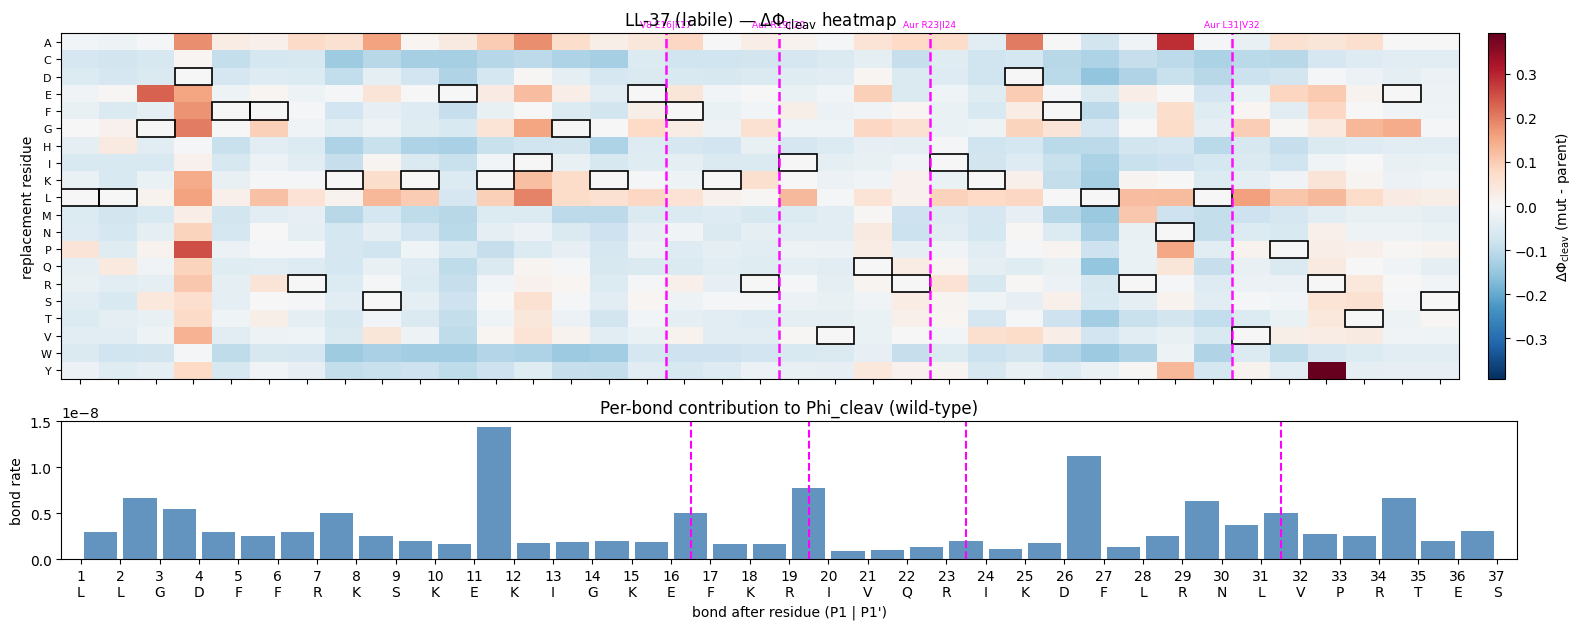

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_ll_37.png


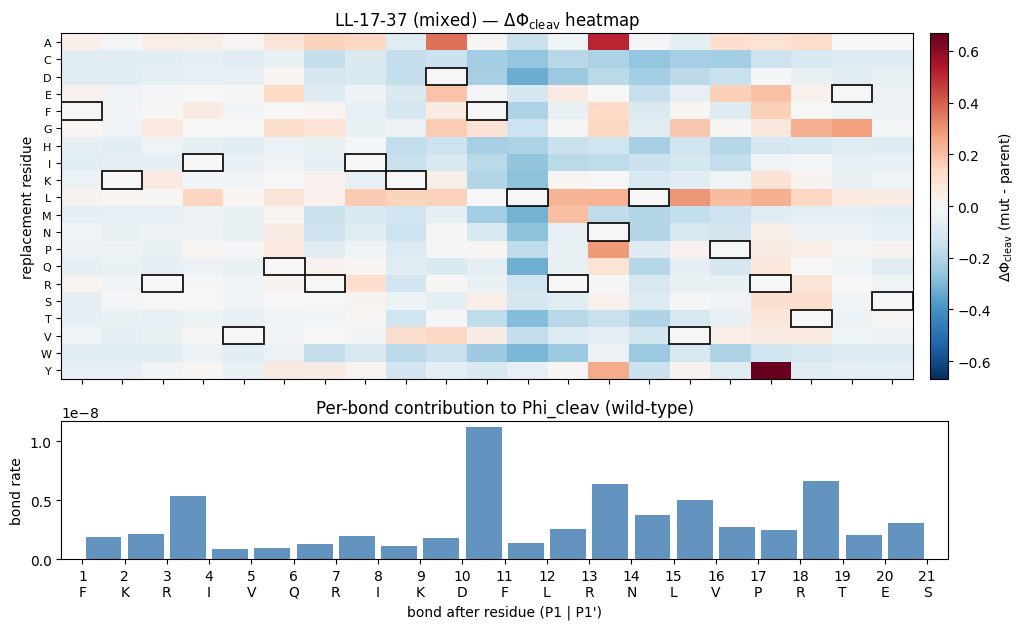

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_ll_17_37.png


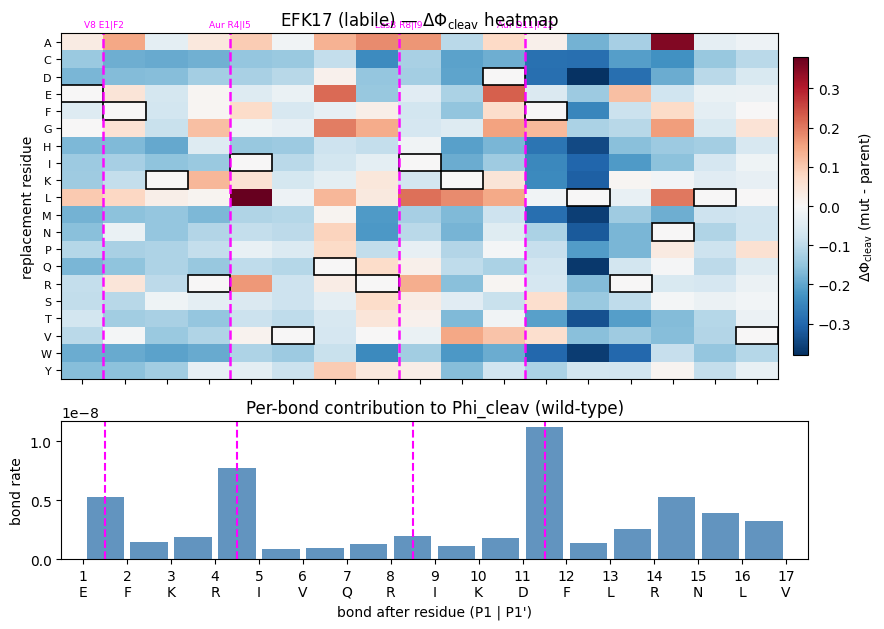

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_efk17.png


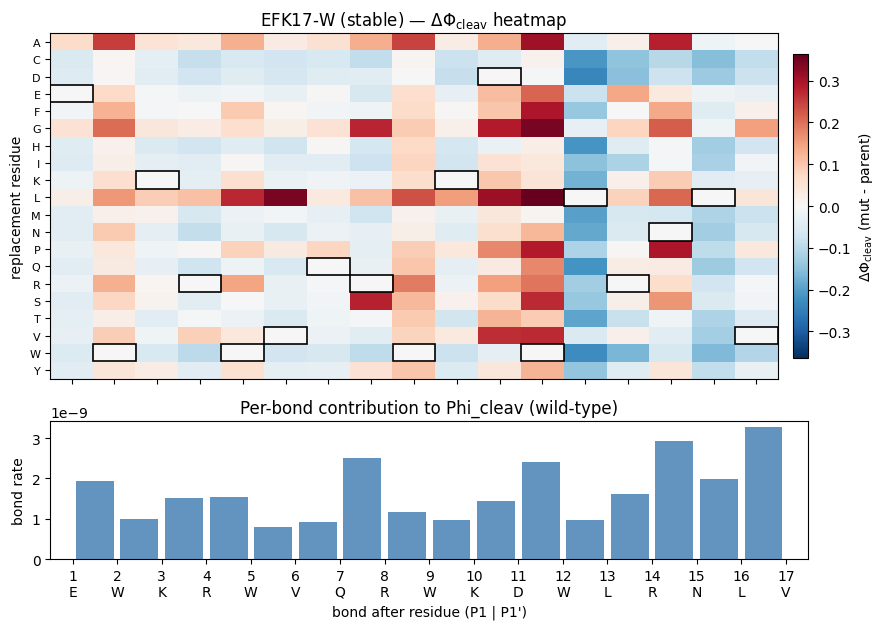

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_efk17_w.png


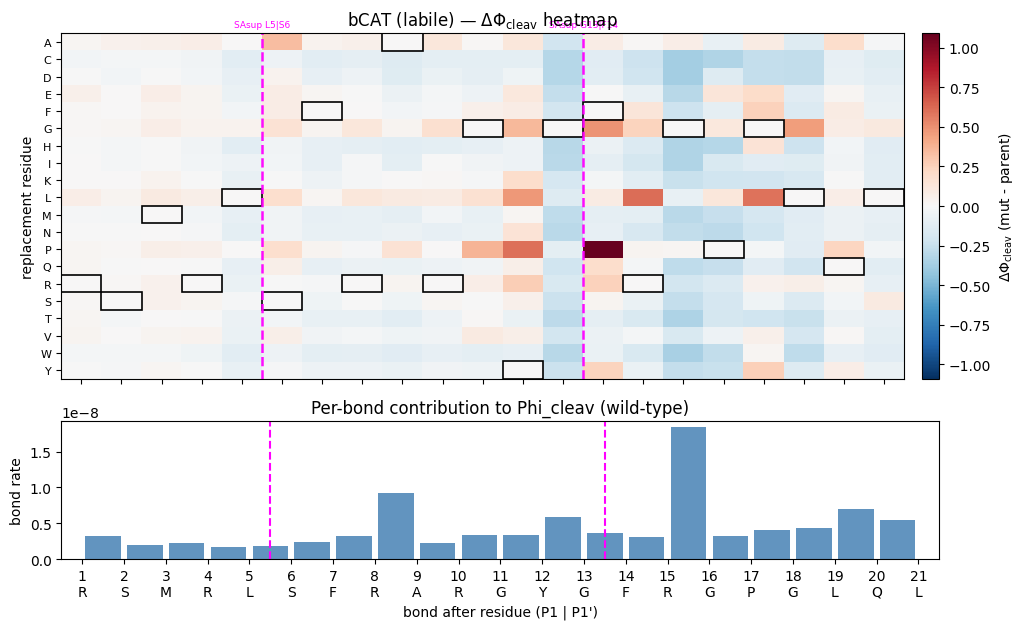

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_bcat.png


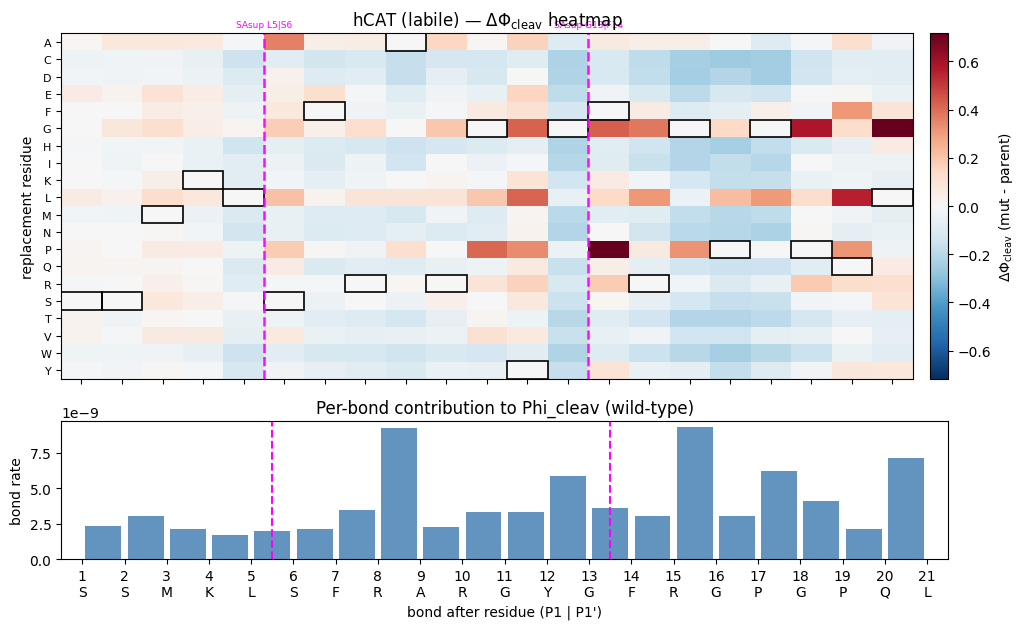

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_hcat.png


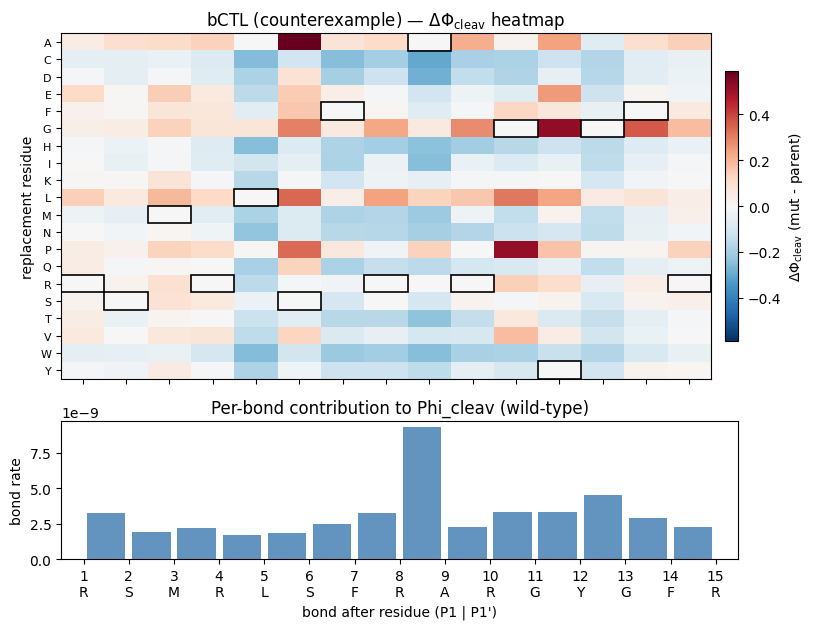

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_bctl.png


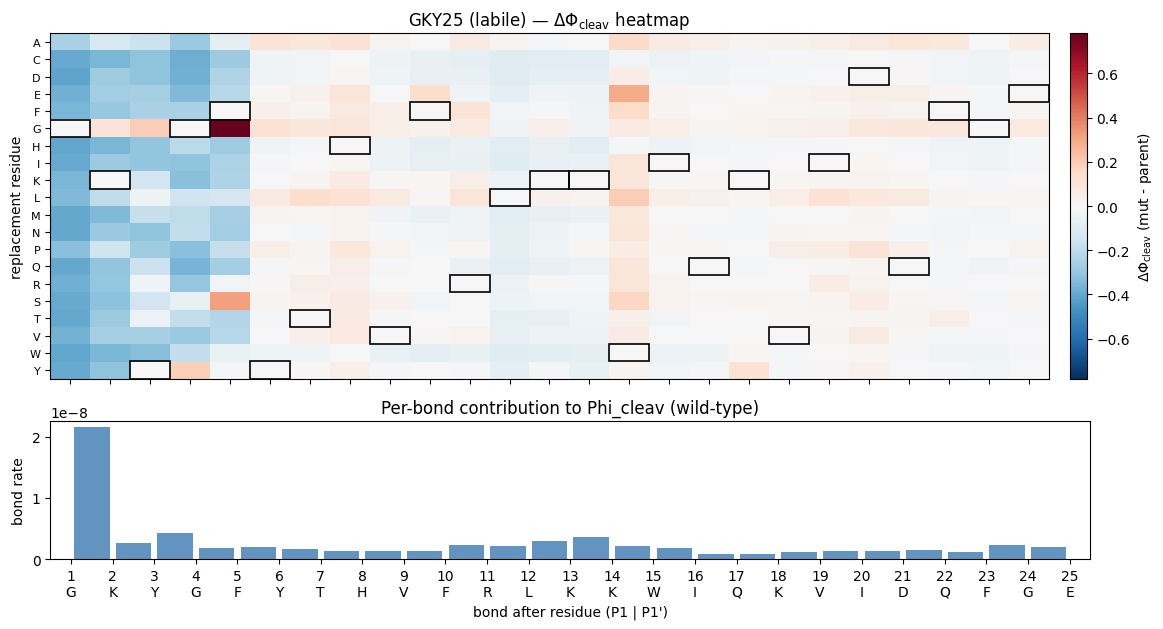

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_gky25.png


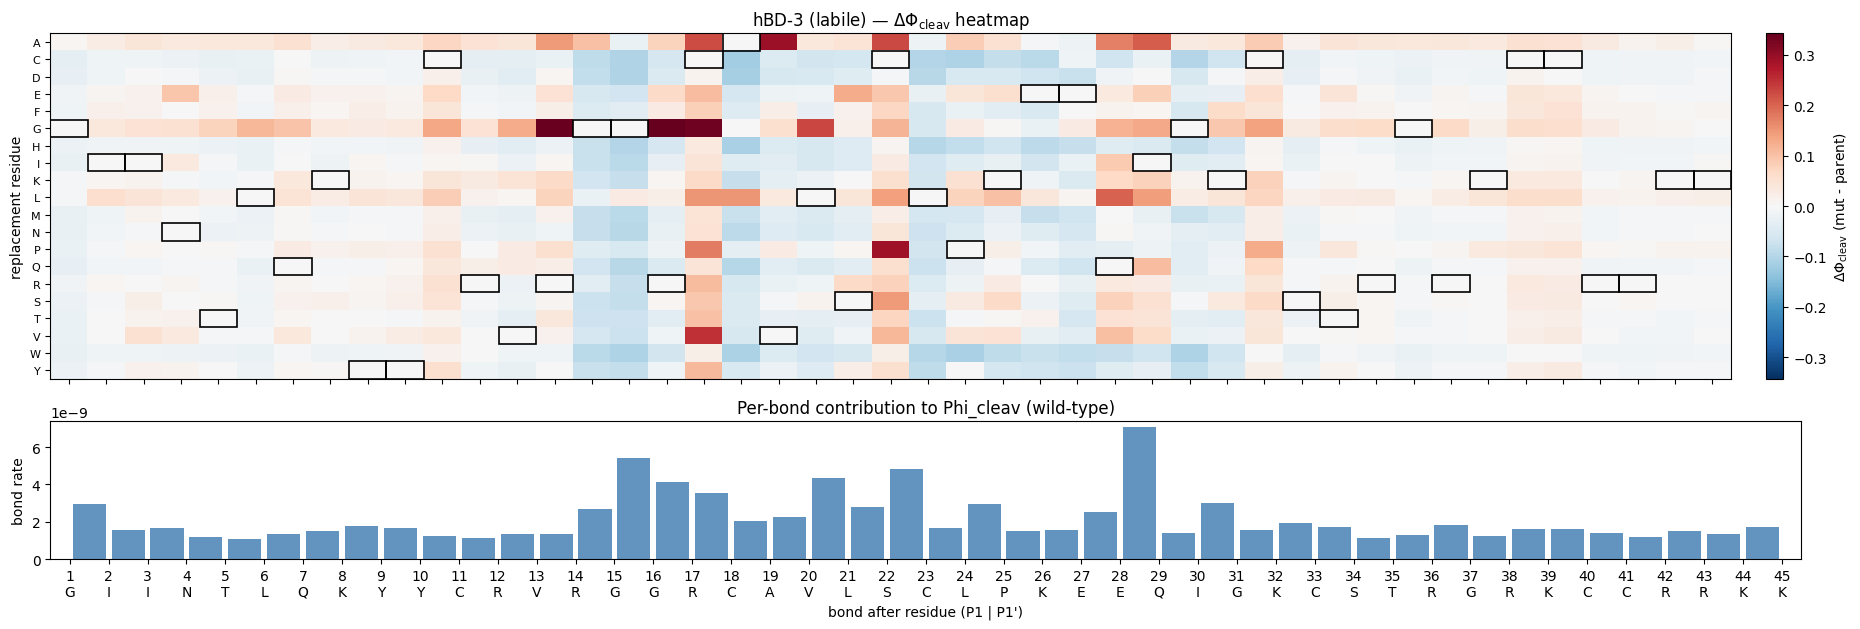

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_hbd_3.png


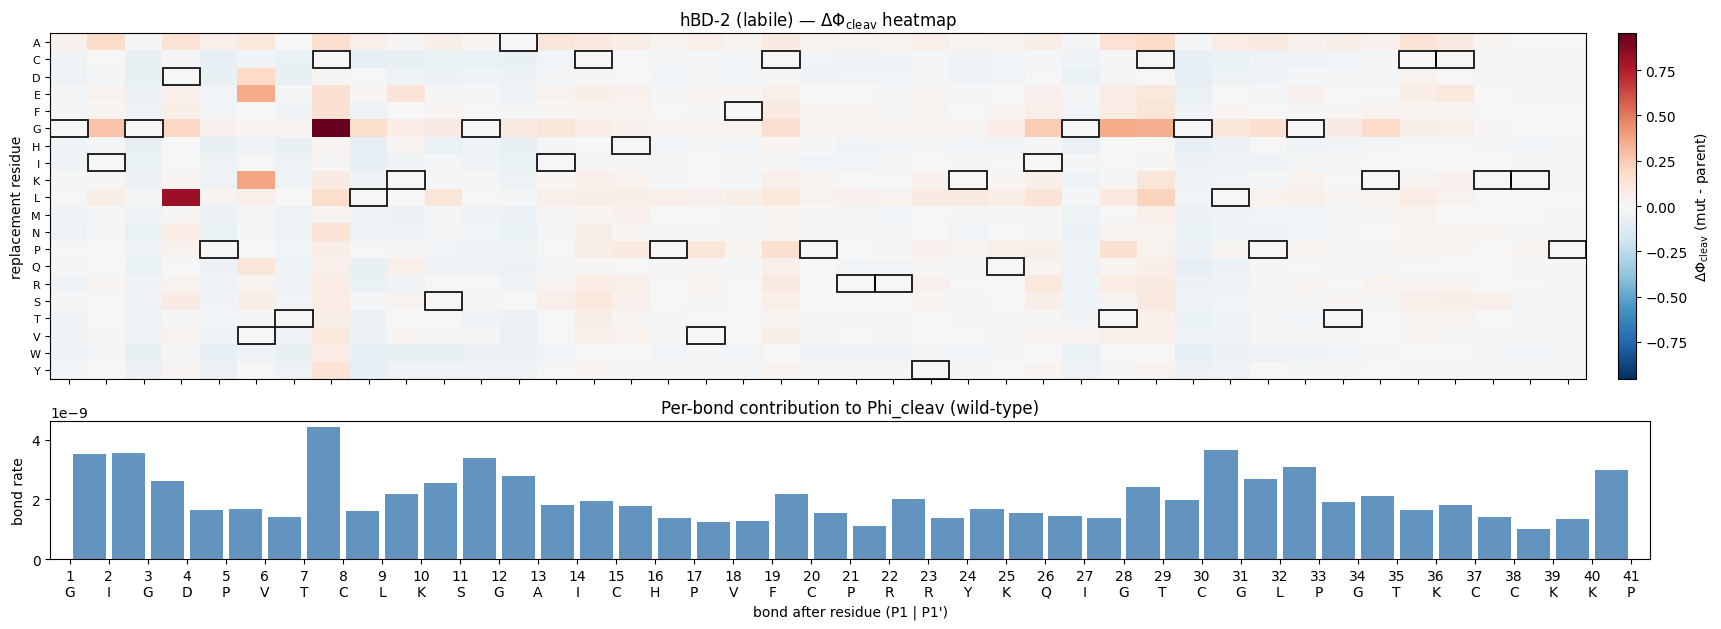

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_hbd_2.png


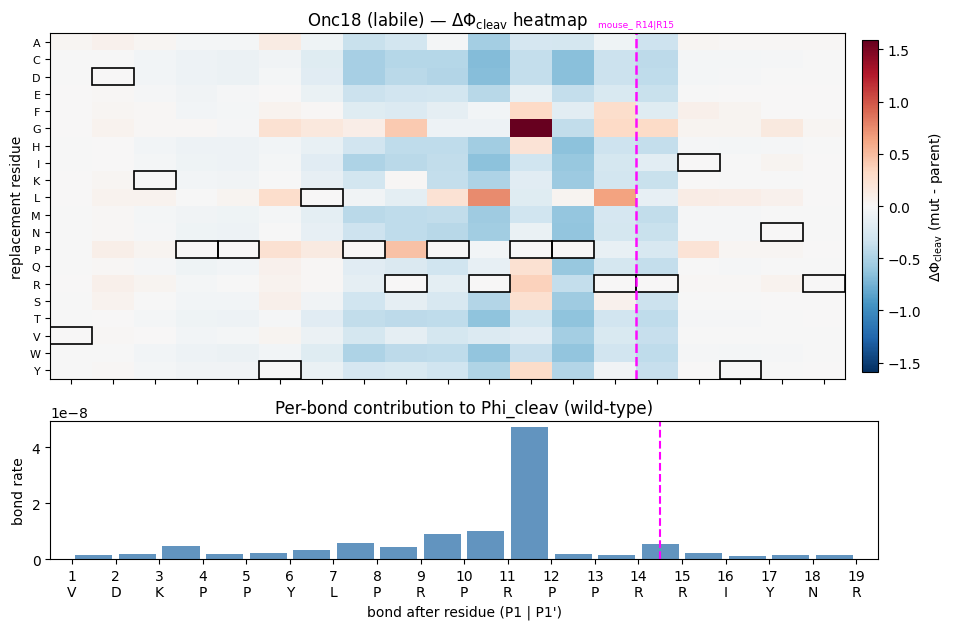

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_onc18.png


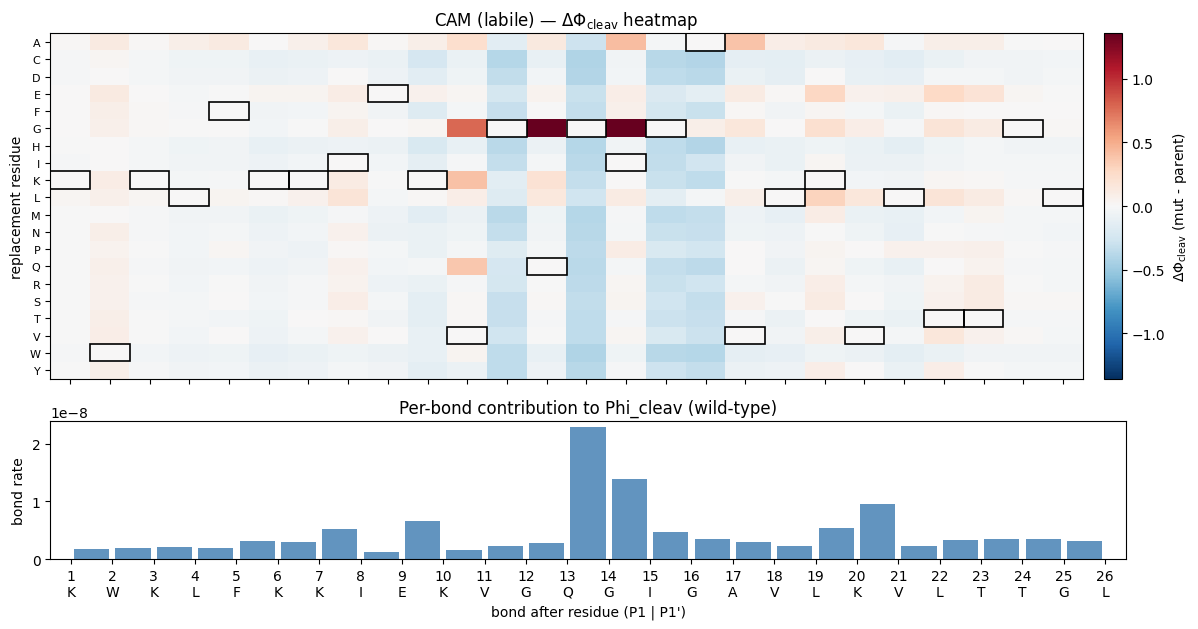

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_cam.png


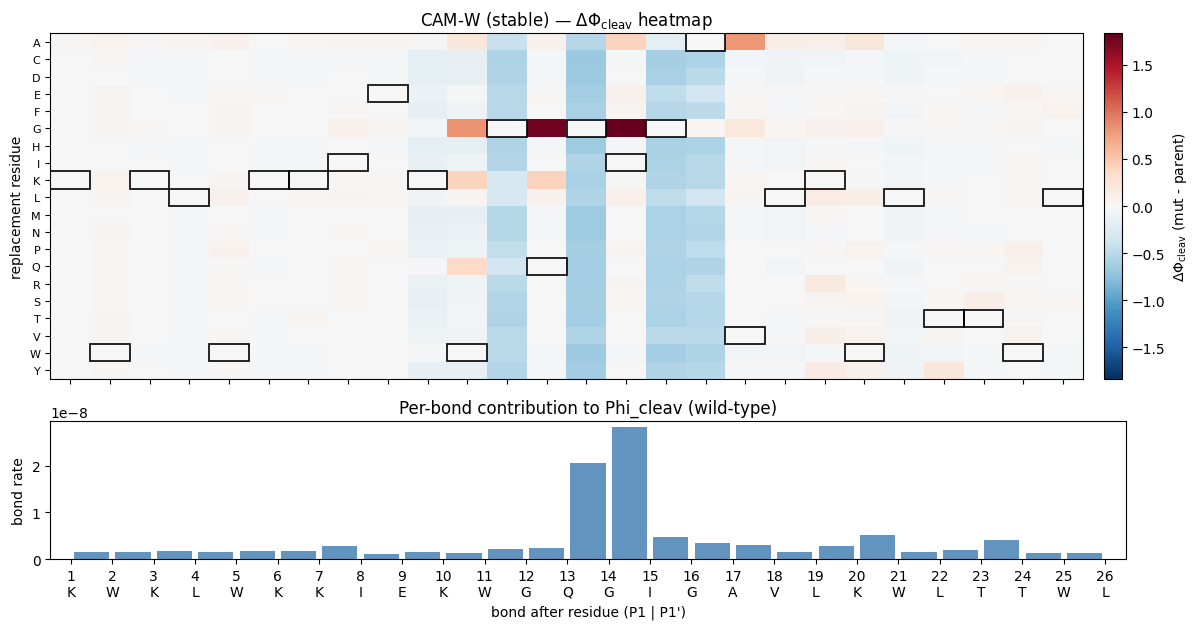

wrote /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures/heatmap_delta_cleavage_cam_w.png


In [6]:
from pep_compass.optimization.components.helpers.proteolysis import MEROPS_AMINO_ACIDS

AA_LIST = list(MEROPS_AMINO_ACIDS)
AA_IDX = [cleavage.alphabet.index(aa) for aa in AA_LIST]


def mutation_delta_matrix(sequence: str) -> np.ndarray:
    length = len(sequence)
    mutations = {pos: AA_IDX for pos in range(length)}
    scores = cleavage.compute(sequence, mutations)
    mat = np.zeros((len(AA_LIST), length), dtype=np.float64)
    for pos in range(length):
        for aa_i, aa in enumerate(AA_LIST):
            mat[aa_i, pos] = scores[pos][AA_IDX[aa_i]]
    return mat


def plot_control_heatmap(
    sequence: str,
    title: str,
    out_path: Path,
    known_bonds: list | None = None,
    bond_contrib: np.ndarray | None = None,
):
    mat = mutation_delta_matrix(sequence)
    length = len(sequence)
    known_bonds = known_bonds or []

    vmax = float(np.nanmax(np.abs(mat))) if mat.size else 1.0
    vmax = max(vmax, 1e-6)

    n_panels = 2 if bond_contrib is not None else 1
    fig_h = 4.2 + (2.2 if n_panels == 2 else 0)
    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(max(8, 0.35 * length + 3), fig_h),
        gridspec_kw={"height_ratios": [3, 1.2]} if n_panels == 2 else None,
        sharex=True,
    )
    ax = axes[0] if n_panels == 2 else axes

    im = ax.imshow(
        mat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest",
    )
    ax.set_yticks(range(len(AA_LIST)))
    ax.set_yticklabels(AA_LIST, fontsize=8)
    ax.set_xticks(range(length))
    ax.set_xticklabels([f"{i + 1}\n{aa}" for i, aa in enumerate(sequence)], fontsize=7)
    ax.set_ylabel("replacement residue")
    ax.set_title(title)

    for pos, aa in enumerate(sequence):
        if aa in AA_LIST:
            yi = AA_LIST.index(aa)
            ax.add_patch(
                plt.Rectangle(
                    (pos - 0.5, yi - 0.5), 1, 1,
                    fill=False, edgecolor="black", lw=1.2,
                )
            )

    for bond_i, label in known_bonds:
        if 0 <= bond_i < length - 1:
            x = bond_i + 0.5
            ax.axvline(x, color="magenta", lw=1.8, ls="--", alpha=0.95)
            ax.text(
                x, -1.3, label, color="magenta", fontsize=6.5,
                ha="center", va="top", rotation=0, clip_on=False,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label(r"$\Delta\Phi_{\mathrm{cleav}}$ (mut - parent)")

    if bond_contrib is not None:
        axb = axes[1]
        xpos = np.arange(len(bond_contrib)) + 0.5
        axb.bar(xpos, bond_contrib, width=0.85, color="steelblue", alpha=0.85)
        for bond_i, label in known_bonds:
            if 0 <= bond_i < len(bond_contrib):
                axb.axvline(bond_i + 0.5, color="magenta", lw=1.5, ls="--")
        axb.set_xlim(-0.5, length - 0.5)
        axb.set_xlabel("bond after residue (P1 | P1')")
        axb.set_ylabel("bond rate" if VARIANT == "product" else "bond score")
        axb.set_title("Per-bond contribution to Phi_cleav (wild-type)")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("wrote", out_path)


bond_list = cleavage.sequence_bond_contributions(peptides["sequence"].tolist())
peptides["bond_contrib"] = bond_list

for _, row in peptides.iterrows():
    name = row["peptide_id"]
    seq = row["sequence"]
    role = row["primary_role"]
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", str(name)).strip("_").lower()
    out = OUT_DIR / f"heatmap_delta_cleavage_{safe}.png"
    plot_control_heatmap(
        seq,
        title=rf"{name} ({role}) — $\Delta\Phi_{{\mathrm{{cleav}}}}$ heatmap",
        out_path=out,
        known_bonds=KNOWN_BONDS.get(name, []),
        bond_contrib=row["bond_contrib"],
    )


## Per-enzyme aureolysin / V8 + CLASP ± APEX SD

`Φ_π = log R_π` from `sequence_protease_rates` (no panel weights). CLASP error bars
are the SD of `log2 MIC` across the APEX ensemble (Φ fixed).


 peptide   primary_role enzyme_code                        enzyme         rate   log_rate
   LL-37         labile     M04.009              aureolysin (Aur) 1.035475e-08 -18.385820
   LL-37         labile     S01.269 V8 / glutamyl endopeptidase I 1.640360e-08 -17.925765
LL-17-37          mixed     M04.009              aureolysin (Aur) 6.658155e-09 -18.827423
LL-17-37          mixed     S01.269 V8 / glutamyl endopeptidase I 1.361155e-09 -20.414933
   EFK17         labile     M04.009              aureolysin (Aur) 8.393592e-09 -18.595797
   EFK17         labile     S01.269 V8 / glutamyl endopeptidase I 1.857804e-09 -20.103871
 EFK17-W         stable     M04.009              aureolysin (Aur) 1.178197e-09 -20.559281
 EFK17-W         stable     S01.269 V8 / glutamyl endopeptidase I 4.588538e-11 -23.804875
    bCAT         labile     M04.009              aureolysin (Aur) 2.081105e-09 -19.990367
    bCAT         labile     S01.269 V8 / glutamyl endopeptidase I 1.043682e-10 -22.983096
    bCTL c

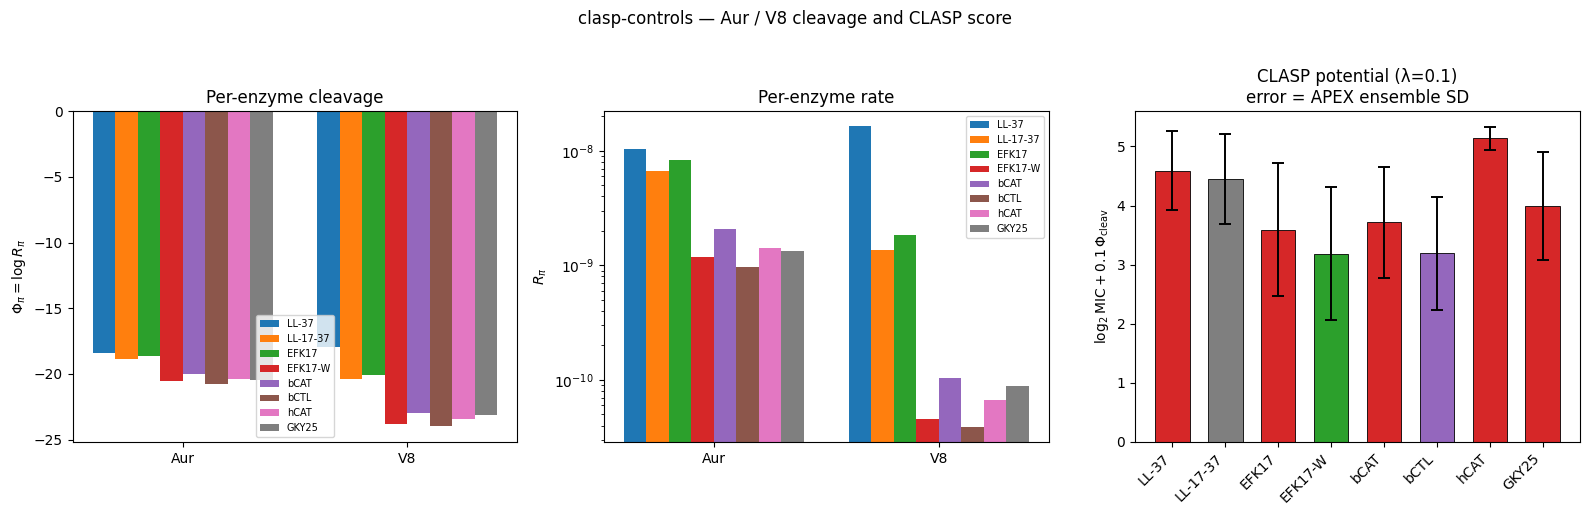

In [7]:
FOCUS_PEPTIDES = [
    "LL-37", "LL-17-37", "EFK17", "EFK17-W", "bCAT", "bCTL", "hCAT", "GKY25",
]
plot_peptides = [p for p in FOCUS_PEPTIDES if p in set(peptides["peptide_id"])]
for p in peptides["peptide_id"]:
    if p not in plot_peptides:
        plot_peptides.append(p)

sub = peptides.set_index("peptide_id").loc[plot_peptides].reset_index()
rates, codes = cleavage.sequence_protease_rates(sub["sequence"].tolist())
code_to_col = {code: i for i, code in enumerate(codes)}

enz_rows = []
for pep_i, (_, row) in enumerate(sub.iterrows()):
    for code, label in FOCUS_ENZYMES.items():
        if code not in code_to_col:
            raise KeyError(f"{code} not in MEROPS panel codes")
        col = code_to_col[code]
        rate = float(rates[pep_i, col])
        enz_rows.append(
            {
                "peptide": row["peptide_id"],
                "primary_role": row["primary_role"],
                "enzyme_code": code,
                "enzyme": label,
                "rate": rate,
                "log_rate": float(np.log(max(rate, 1e-30))),
            }
        )
enz_df = pd.DataFrame(enz_rows)
enz_path = OUT_DIR / "per_enzyme_aureolysin_v8_scores.csv"
enz_df.to_csv(enz_path, index=False)
print(enz_df.to_string(index=False))
print("wrote", enz_path)

pep_to_i = {pid: i for i, pid in enumerate(peptides["peptide_id"])}
clasp_rows = []
for _, row in sub.iterrows():
    i = pep_to_i[row["peptide_id"]]
    clasp_rows.append(
        {
            "peptide": row["peptide_id"],
            "primary_role": row["primary_role"],
            "phi_cleav": float(row["cleavage"]),
            "mic_mean": float(mic_ens[:, i].mean()),
            "mic_sd": float(mic_ens[:, i].std(ddof=1)),
            "log2_mic_mean": float(log2_ens[:, i].mean()),
            "log2_mic_sd": float(log2_ens[:, i].std(ddof=1)),
            "potential_mean": float(log2_ens[:, i].mean() + LAM * row["cleavage"]),
            "potential_sd": float(log2_ens[:, i].std(ddof=1)),
            "n_ensemble": int(mic_ens.shape[0]),
            "lambda": LAM,
        }
    )
clasp_df = pd.DataFrame(clasp_rows)
clasp_path = OUT_DIR / "clasp_potential_ensemble.csv"
clasp_df.to_csv(clasp_path, index=False)
print("\n", clasp_df.to_string(index=False))
print("wrote", clasp_path)

show = [p for p in FOCUS_PEPTIDES if p in set(sub["peptide_id"])]
enzymes = list(FOCUS_ENZYMES.values())
x = np.arange(len(enzymes))
width = 0.8 / max(len(show), 1)
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.0))

ax = axes[0]
for j, pep in enumerate(show):
    vals = [
        float(
            enz_df.loc[
                (enz_df["peptide"] == pep) & (enz_df["enzyme"] == enz), "log_rate"
            ].iloc[0]
        )
        for enz in enzymes
    ]
    ax.bar(
        x + (j - (len(show) - 1) / 2) * width,
        vals,
        width,
        label=pep,
        color=cmap(j % 10),
    )
ax.set_xticks(x)
ax.set_xticklabels(["Aur", "V8"])
ax.set_ylabel(r"$\Phi_\pi = \log R_\pi$")
ax.set_title("Per-enzyme cleavage")
ax.legend(fontsize=7, loc="best")

ax = axes[1]
for j, pep in enumerate(show):
    vals = [
        float(
            enz_df.loc[
                (enz_df["peptide"] == pep) & (enz_df["enzyme"] == enz), "rate"
            ].iloc[0]
        )
        for enz in enzymes
    ]
    ax.bar(
        x + (j - (len(show) - 1) / 2) * width,
        vals,
        width,
        label=pep,
        color=cmap(j % 10),
    )
ax.set_xticks(x)
ax.set_xticklabels(["Aur", "V8"])
ax.set_ylabel(r"$R_\pi$")
ax.set_yscale("log")
ax.set_title("Per-enzyme rate")
ax.legend(fontsize=7, loc="best")

ax = axes[2]
xp = np.arange(len(show))
means = [float(clasp_df.loc[clasp_df["peptide"] == pep, "potential_mean"].iloc[0]) for pep in show]
sds = [float(clasp_df.loc[clasp_df["peptide"] == pep, "potential_sd"].iloc[0]) for pep in show]
colors = [
    ROLE_COLORS.get(
        str(clasp_df.loc[clasp_df["peptide"] == pep, "primary_role"].iloc[0]), "#7f7f7f"
    )
    for pep in show
]
ax.bar(
    xp,
    means,
    yerr=sds,
    color=colors,
    capsize=4,
    width=0.65,
    error_kw={"elinewidth": 1.4, "capthick": 1.4},
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xticks(xp)
ax.set_xticklabels(show, rotation=45, ha="right")
ax.set_ylabel(rf"$\log_2\mathrm{{MIC}} + {LAM:g}\,\Phi_{{\mathrm{{cleav}}}}$")
ax.set_title(f"CLASP potential (λ={LAM})\nerror = APEX ensemble SD")

fig.suptitle("clasp-controls — Aur / V8 cleavage and CLASP score", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "per_enzyme_aureolysin_v8_and_clasp.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
print("Outputs in", OUT_DIR)
for path in sorted(OUT_DIR.iterdir()):
    print(" -", path.name)


Outputs in /home/max/repositories/pep-compass/experiments/results/clasp_controls_figures
 - clasp_controls_annotations_long.csv
 - clasp_potential_ensemble.csv
 - cleavage_and_potential_histograms.png
 - controls_figure_table.csv
 - dbaasp_saureus_cleavage.csv
 - heatmap_delta_cleavage_bcat.png
 - heatmap_delta_cleavage_bctl.png
 - heatmap_delta_cleavage_cam.png
 - heatmap_delta_cleavage_cam_w.png
 - heatmap_delta_cleavage_efk17.png
 - heatmap_delta_cleavage_efk17_w.png
 - heatmap_delta_cleavage_gky25.png
 - heatmap_delta_cleavage_hbd_2.png
 - heatmap_delta_cleavage_hbd_3.png
 - heatmap_delta_cleavage_hcat.png
 - heatmap_delta_cleavage_ll_17_37.png
 - heatmap_delta_cleavage_ll_37.png
 - heatmap_delta_cleavage_onc18.png
 - length_vs_cleavage_and_potential_scatter.png
 - per_enzyme_aureolysin_v8_and_clasp.png
 - per_enzyme_aureolysin_v8_scores.csv
